In [1]:
# Cella 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter, defaultdict
import numpy as np

# Configurazione grafici
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Setup completato.")

Setup completato.


In [2]:
ds = load_dataset("nvidia/Nemotron-PII")

df = ds["train"].to_pandas()
df.head()

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/156M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/151M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100000 [00:00<?, ? examples/s]

,uid,domain,document_type,document_description,document_format,locale,text,spans,text_tagged
0,058211ab4d324e3a9e5b83c557a341d6,Identity Verification Services,Financial Services Application,"This document, typically found in the Identity...",unstructured,us,"I, Jason, am applying for a financial services...","[{'start': 3, 'end': 8, 'text': 'Jason', 'labe...","I, [Jason]first_name, am applying for a financ..."
1,564aaab4a96a4afba303c9d702ce435e,Healthcare,blood donor registration form,The healthcare blood donor registration form i...,unstructured,us,**Blood Donor Registration Form**\n\nThank you...,"[{'start': 220, 'end': 228, 'text': 'Patricia'...",**Blood Donor Registration Form**\n\nThank you...
2,1f1e650b4c7f42cd822cc53d4a1a3399,Logistics,Bill of Lading,A Bill of Lading in the logistics domain is an...,unstructured,us,SwiftFlow Logistics has issued this Bill of La...,"[{'start': 0, 'end': 19, 'text': 'SwiftFlow Lo...",[SwiftFlow Logistics]company_name has issued t...
3,7167c6f50a2c4bd6b349163980c79c71,Identity Verification Services,Emergency Contact Form,An unstructured Emergency Contact Form for Ide...,unstructured,us,"Maria, born on 2002-03-05, is a Spanish indivi...","[{'start': 0, 'end': 5, 'text': 'Maria', 'labe...","[Maria]first_name, born on [2002-03-05]date_of..."
4,f6eefc3133614611a421681c3d9df1b5,Identity Verification Services,Legal Correspondence Cover Page,This structured document is a legal correspond...,structured,us,**VeriTrust ID**\n\n**Legal Correspondence Cov...,"[{'start': 2, 'end': 14, 'text': 'VeriTrust ID...",**[VeriTrust ID]company_name**\n\n**Legal Corr...


In [3]:
print("Shape:", df.shape)
print("\nColumns: ", df.columns.tolist())

for i in range(len(df.columns)):
    col = df.columns[i]
    print(f"\nColumn {i + 1}: '{col}'")
    print("Sample data:", df[col].iloc[0])

Shape: (100000, 9)

Columns:  ['uid', 'domain', 'document_type', 'document_description', 'document_format', 'locale', 'text', 'spans', 'text_tagged']

Column 1: 'uid'
Sample data: 058211ab4d324e3a9e5b83c557a341d6

Column 2: 'domain'
Sample data: Identity Verification Services

Column 3: 'document_type'
Sample data: Financial Services Application

Column 4: 'document_description'
Sample data: This document, typically found in the Identity Verification Services and Financial Services domains, is an unstructured application form featuring handwritten or typed responses, including fields for personal identification details such as name, date of birth, and address, along with financial information like income and employment status, and often includes scanned or attached copies of identification documents and signatures.

Column 5: 'document_format'
Sample data: unstructured

Column 6: 'locale'
Sample data: us

Column 7: 'text'
Sample data: I, Jason, am applying for a financial services acco

Unique domains 30

Top 10 domains
domain
Finance                           3990
Technology                        3988
Cybersecurity                     3890
Identity Management               3750
Identity Verification Services    3722
Telecommunications                3662
Healthcare                        3630
Government                        3566
Civil Rights                      3546
Ecommerce                         3514
Name: count, dtype: int64


/tmp/ipykernel_246912/3868666521.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


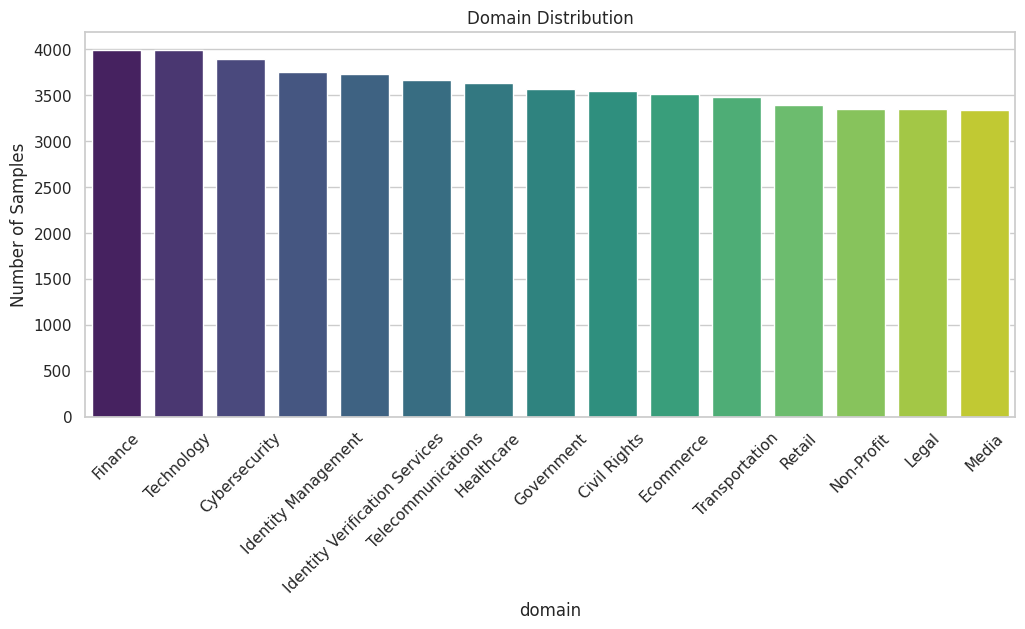

In [5]:
if "domain" in df.columns:
    domain_counts = df["domain"].value_counts()
    print("Unique domains", len(domain_counts))
    print("\nTop 10 domains")
    print(domain_counts.head(10))

    plt.figure(figsize=(12, 5))
    sns.barplot(
        x=domain_counts.head(15).index, y=domain_counts.head(15).values, palette="viridis"
    )
    plt.title("Domain Distribution")
    plt.ylabel("Number of Samples")
    plt.xlabel("domain")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Colonna 'domain' non trovata.")

Numero totale di etichette trovate: 825456
Tipi di PII unici: 55

Total entities found: 825456

Top PII Classes:
                                count
company_name                    85441
date                            77130
first_name                      59391
email                           49934
url                             44803
last_name                       43962
occupation                      31105
country                         27781
phone_number                    25012
time                            21054
city                            19313
state                           19067
customer_id                     17211
street_address                  16830
date_time                       14368
user_name                       12872
date_of_birth                   12710
employee_id                     12067
biometric_identifier            11188
education_level                 10633
account_number                   9998
vehicle_identifier               9339
credit_debit_

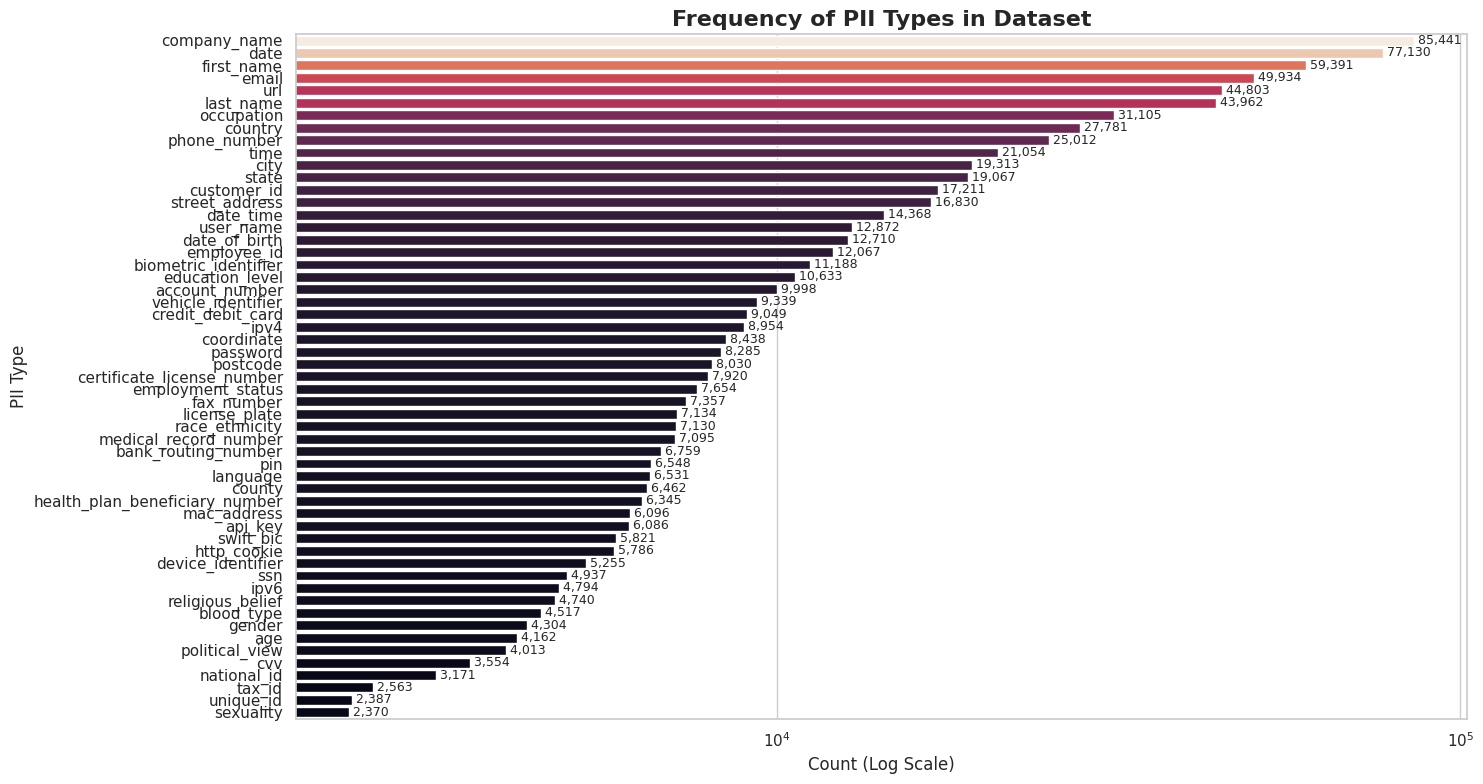

In [13]:
import json
import ast
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_pii_counts(df_column):
    all_labels = []
    for span_list in df_column:
        # Gestisci diversi formati
        if isinstance(span_list, str):
            try:
                # Prova prima con ast.literal_eval (più sicuro per liste Python)
                span_list = ast.literal_eval(span_list)
            except:
                try:
                    # Se fallisce, prova con json.loads
                    span_list = json.loads(span_list)
                except:
                    continue
        
        if isinstance(span_list, list):
            for item in span_list:
                if isinstance(item, dict):
                    label = item.get("label")
                    if label:
                        all_labels.append(label)
    return Counter(all_labels)

# Analisi PII
pii_counts = get_pii_counts(df["spans"])

print(f"Numero totale di etichette trovate: {sum(pii_counts.values())}")
print(f"Tipi di PII unici: {len(pii_counts)}\n")

if len(pii_counts) == 0:
    print("⚠️ ERRORE: Nessuna entità PII trovata!")
    print("\nControllo tipo di dato:")
    print(f"Tipo: {type(df['spans'].iloc[0])}")
    print(f"Primo elemento: {df['spans'].iloc[0]}")
else:
    df_pii = pd.DataFrame.from_dict(
        pii_counts, orient="index", columns=["count"]
    ).sort_values("count", ascending=False)
    
    print(f"Total entities found: {df_pii['count'].sum()}")
    print("\nTop PII Classes:")
    print(df_pii)
    
    # Plot
    plt.figure(figsize=(15, 8))
    ax = sns.barplot(
        x=df_pii["count"].values,
        y=df_pii.index,
        palette="rocket",
        hue=df_pii["count"].values,
        dodge=False,
        legend=False
    )
    
    # Aggiungi i valori sulle barre
    for i, v in enumerate(df_pii["count"].values):
        ax.text(v, i, f' {v:,}', va='center', fontsize=9)
    
    plt.title("Frequency of PII Types in Dataset", fontsize=16, fontweight='bold')
    plt.xlabel("Count (Log Scale)", fontsize=12)
    plt.xscale("log")
    plt.ylabel("PII Type", fontsize=12)
    plt.tight_layout()
    plt.show()


Length stats (approximated tokens):
count    100000.000000
mean        134.525810
std          99.335153
min           2.000000
25%          67.000000
50%         103.000000
75%         171.000000
max        1303.000000
Name: text_len_tokens_approx, dtype: float64


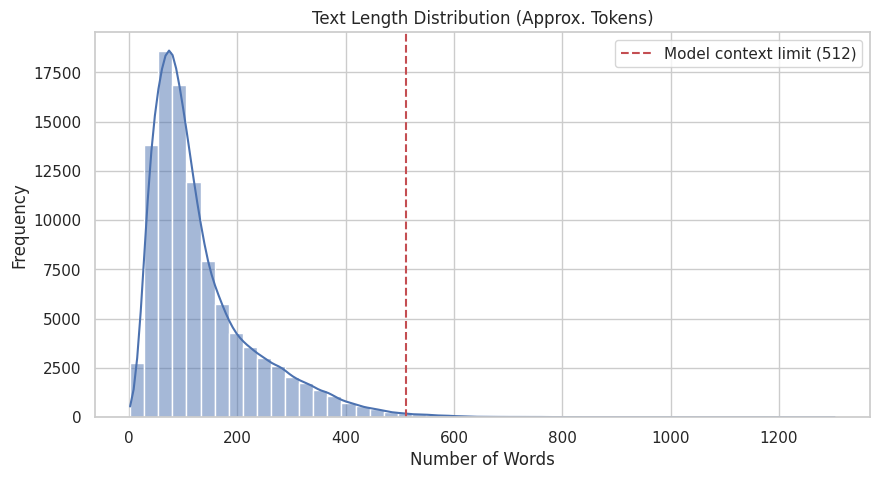

Text % > 512 words: 0.56%


In [9]:
df['text_len_chars'] = df['text'].str.len()
df['text_len_tokens_approx'] = df['text'].str.split().str.len()
print("\nLength stats (approximated tokens):")
print(df['text_len_tokens_approx'].describe())

# Visualization
plt.figure(figsize=(10, 5))
sns.histplot(df['text_len_tokens_approx'], bins=50, kde=True)
plt.axvline(x=512, color='r', linestyle='--', label='Model context limit (512)')
plt.title("Text Length Distribution (Approx. Tokens)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Percentage over 512
over_512 = (df['text_len_tokens_approx'] > 512).mean() * 100
print(f"Text % > 512 words: {over_512:.2f}%")

In [10]:
def print_annotated_text(text, span_list):
   sorted_spans = []
   if isinstance(span_list, list):
      for item in span_list:
         if isinstance(item, dict):
               sorted_spans.append((item['start'], item['end'], item['label']))
   
   sorted_spans.sort(key=lambda x: x[0])
   
   output = ""
   prev_end = 0
   for start, end, label in sorted_spans:
      output += text[prev_end:start]
      masked_segment = text[start:end]
      output += f"\033[91m[{masked_segment}]({label})\033[0m"
      prev_end = end
   output += text[prev_end:]
   return output

# Sample display
samples = df.sample(3)
for idx, row in samples.iterrows():
   print(f"\nUID: {row['uid']} | Domain: {row['domain']} | Locale: {row['locale']}")
   try:
      print(print_annotated_text(row['text'], row['spans']))
   except Exception as e:
      print(f"Visualization error: {e}")
      print(row['text'][:200] + "...")
   print("-" * 80)


UID: c1cbe4a0ef6a422ab700d4dadd7dec06 | Domain: Consumer Goods | Locale: intl
This Customer Service Agreement is entered into on 07/15/2028 between CasaSoluciones and the customer, for the provision of consumer goods services. For any inquiries or support, please contact alex.p@casasoluciones.co. This agreement outlines the terms and conditions under which CasaSoluciones will provide services to the customer. The Effective Date of this agreement is 07/15/2028. The customer, identified by the race ethnicity Wayuu and social security number 452-55-1370, acknowledges having read and understood the terms outlined in this agreement, including the Termination Clause. The customer can access the full agreement at https://bestbuy.com/customer-service/agreements?document_type=Customer+Service+Agreement&year=2023. The customer must have a valid cookie with the name user_session=qwerty987654321 to access the services. The signatures of the parties involved will be affixed below, indicating their